In [1]:
# Import all libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib

# Load preprocessed data that we saved on Day 3
X_train = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\X_train.npy')
X_test  = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\X_test.npy')
y_train = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\y_train.npy')
y_test  = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\y_test.npy')

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data loaded successfully!
X_train shape: (454902, 30)
X_test shape: (56962, 30)
y_train shape: (454902,)
y_test shape: (56962,)


In [2]:
# K-Means Clustering
# We use 2 clusters - one for normal, one for suspicious transactions
kmeans = KMeans(n_clusters=2, random_state=42)

# Train K-Means on training data
kmeans.fit(X_train)

# Predict clusters for test data
clusters = kmeans.predict(X_test)

print("K-Means Training done!")
print("Cluster 0 count:", sum(clusters == 0))
print("Cluster 1 count:", sum(clusters == 1))

K-Means Training done!
Cluster 0 count: 56918
Cluster 1 count: 44


In [3]:
# Check which cluster represents fraud
import pandas as pd

# Create a dataframe with clusters and actual labels
cluster_df = pd.DataFrame({
    'cluster': clusters,
    'actual': y_test
})

# Check fraud percentage in each cluster
print("Cluster 0 - Fraud percentage:")
cluster0 = cluster_df[cluster_df['cluster'] == 0]
print(f"  Total: {len(cluster0)}")
print(f"  Fraud: {cluster0['actual'].sum()}")
print(f"  Fraud %: {cluster0['actual'].mean()*100:.2f}%")

print("\nCluster 1 - Fraud percentage:")
cluster1 = cluster_df[cluster_df['cluster'] == 1]
print(f"  Total: {len(cluster1)}")
print(f"  Fraud: {cluster1['actual'].sum()}")
print(f"  Fraud %: {cluster1['actual'].mean()*100:.2f}%")

Cluster 0 - Fraud percentage:
  Total: 56918
  Fraud: 65
  Fraud %: 0.11%

Cluster 1 - Fraud percentage:
  Total: 44
  Fraud: 33
  Fraud %: 75.00%


In [4]:
# Save K-Means model
joblib.dump(kmeans, r'C:\Users\Dhairy Jani\upi-fraud-detector\models\kmeans.pkl')

print("K-Means model saved successfully!")

K-Means model saved successfully!


In [5]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees
    class_weight='balanced', # handles class imbalance
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

print("Random Forest Training done!")

Random Forest Training done!


In [6]:
# Test the model on unseen data
y_pred = rf.predict(X_test)

# Classification Report - shows all metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



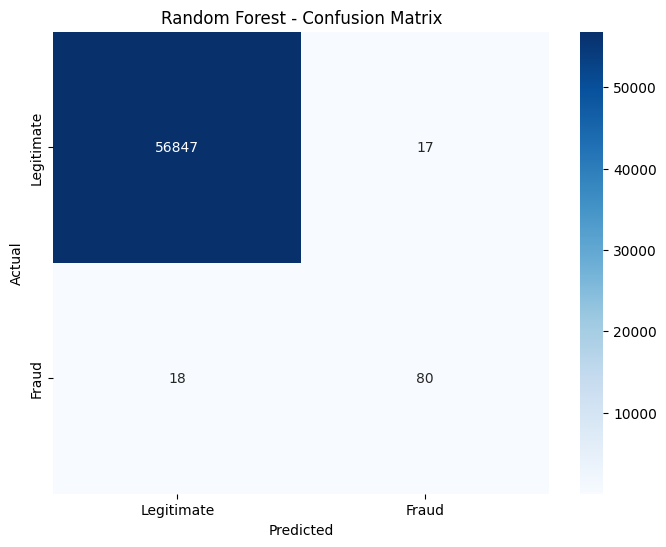

In [7]:
# Confusion Matrix - visual representation of results
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\Dhairy Jani\AppData\Local\Temp\ipykernel_12752\1505064436.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df.head(15), palette='Reds_r')


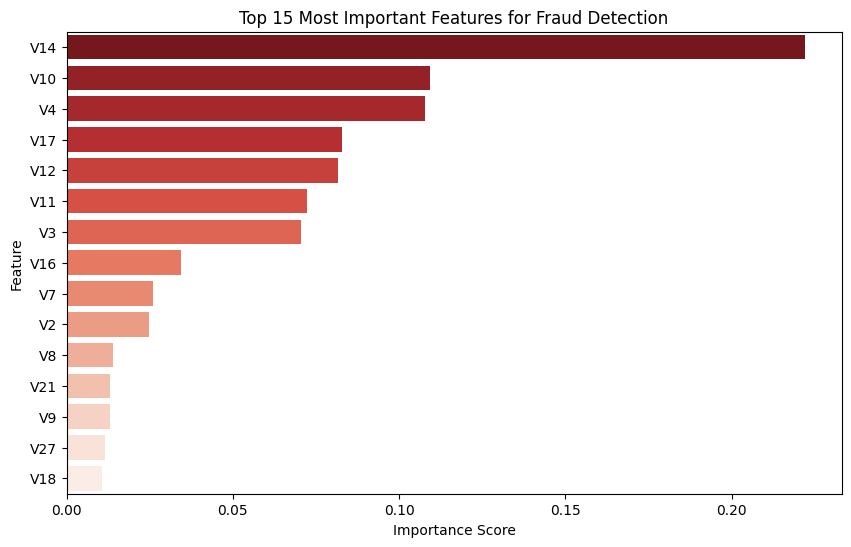


Top 5 Most Important Features:
   Feature  Importance
13     V14    0.221890
9      V10    0.109153
3       V4    0.107627
16     V17    0.082802
11     V12    0.081718


In [8]:
# Feature Importance - which features helped most in detecting fraud
import pandas as pd

# Get feature importance from Random Forest
feature_names = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
importances = rf.feature_importances_

# Create dataframe and sort by importance
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(15), palette='Reds_r')
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_df.head())

In [9]:
# Save Random Forest model
joblib.dump(rf, r'C:\Users\Dhairy Jani\upi-fraud-detector\models\random_forest.pkl')

print("Random Forest model saved successfully!")
print("Location: models/random_forest.pkl")

Random Forest model saved successfully!
Location: models/random_forest.pkl
